## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import squarify
import os
import polars as pl
%matplotlib inline

## Load & Clean Data

In [2]:
CSV_PATH = "/home/chien/Big_Data/product/2019-Oct.csv"
PQ_PATH  = CSV_PATH.replace(".csv", "_zstd.parquet")

if not os.path.exists(PQ_PATH):
    (
        pl.scan_csv(
            CSV_PATH,
            schema_overrides={
                "product_id": pl.Int64,
                "category_id": pl.Int64,
                "user_id":    pl.Int64,
                "price":      pl.Float32,
                "event_time": pl.Utf8,
            },
        )
        .sink_parquet(PQ_PATH, compression="zstd", compression_level=3)
    )
data = (
    pl.scan_parquet(PQ_PATH)
    .filter(
        pl.col("user_session").is_not_null()
        & pl.col("user_id").is_not_null()
        & pl.col("product_id").is_not_null()
    )
    .with_columns(pl.col(["brand", "category_code"]).fill_null("unknown"))
    .collect(streaming=True)
)

/tmp/ipykernel_11614/2630971913.py:19: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  pl.scan_parquet(PQ_PATH)


In [3]:
data.shape

(42448762, 9)

In [4]:
data.schema

Schema([('event_time', String),
        ('event_type', String),
        ('product_id', Int64),
        ('category_id', Int64),
        ('category_code', String),
        ('brand', String),
        ('price', Float32),
        ('user_id', Int64),
        ('user_session', String)])

In [5]:
data.glimpse()

Rows: 42448762
Columns: 9
$ event_time    <str> '2019-10-01 00:00:00 UTC', '2019-10-01 00:00:00 UTC', '2019-10-01 00:00:01 UTC', '2019-10-01 00:00:01 UTC', '2019-10-01 00:00:04 UTC', '2019-10-01 00:00:05 UTC', '2019-10-01 00:00:08 UTC', '2019-10-01 00:00:08 UTC', '2019-10-01 00:00:10 UTC', '2019-10-01 00:00:11 UTC'
$ event_type    <str> 'view', 'view', 'view', 'view', 'view', 'view', 'view', 'view', 'view', 'view'
$ product_id    <i64> 44600062, 3900821, 17200506, 1307067, 1004237, 1480613, 17300353, 31500053, 28719074, 1004545
$ category_id   <i64> 2103807459595387724, 2053013552326770905, 2053013559792632471, 2053013558920217191, 2053013555631882655, 2053013561092866779, 2053013553853497655, 2053013558031024687, 2053013565480109009, 2053013555631882655
$ category_code <str> 'unknown', 'appliances.environment.water_heater', 'furniture.living_room.sofa', 'computers.notebook', 'electronics.smartphone', 'computers.desktop', 'unknown', 'unknown', 'apparel.shoes.keds', 'electronics.smartph

## Visitors Daily Trend

In [6]:
visitor = data.select(pl.col("user_id").n_unique()).item()
visitor

3022290

In [7]:
data = data.with_columns(
    pl.col("event_time")
    .str.slice(0, 10)
    .str.to_date("%Y-%m-%d")
    .alias("event_date")
)

In [8]:
visitor_by_date = (
    data.select(["event_date", "user_id"])
    .unique()
    .group_by("event_date")
    .agg(pl.len().alias("count"))
    .sort("event_date")
)

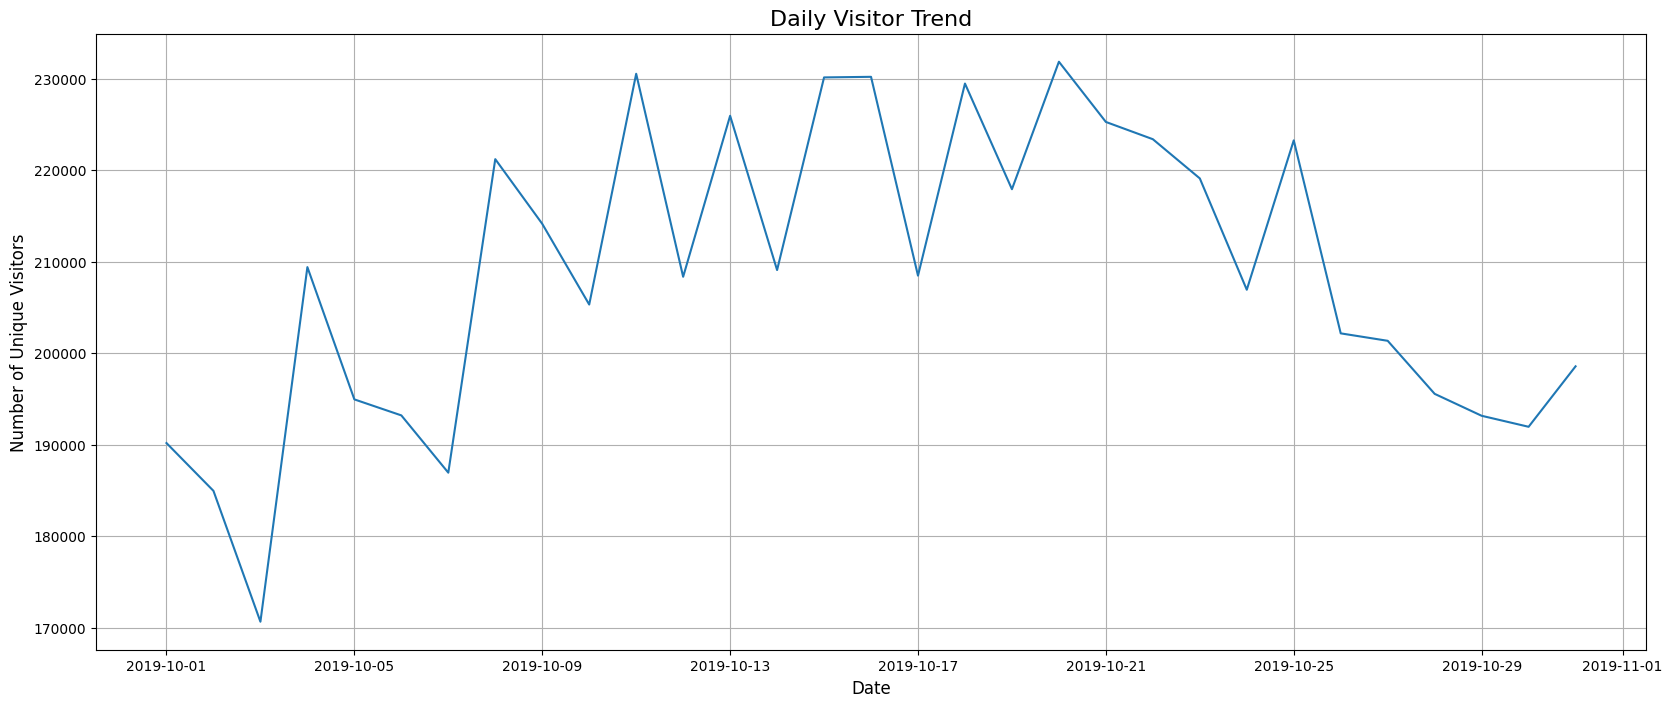

In [9]:
x = visitor_by_date["event_date"]
y = visitor_by_date["count"]

plt.rcParams["figure.figsize"] = (20, 8)
plt.plot(x, y)
plt.title("Daily Visitor Trend", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Unique Visitors", fontsize=12)
plt.grid(True)
plt.show()

## Price Daily Trend

In [10]:
product_id = 1307067
data.filter(pl.col("product_id") == product_id).select(["category_code", "brand"]).head(1)

category_code,brand
str,str
"""computers.notebook""","""lenovo"""


In [11]:
product_daily_price = (
    data.filter(pl.col("product_id") == product_id)
    .group_by("event_date")
    .agg(pl.col("price").mean())
    .sort("event_date")
)

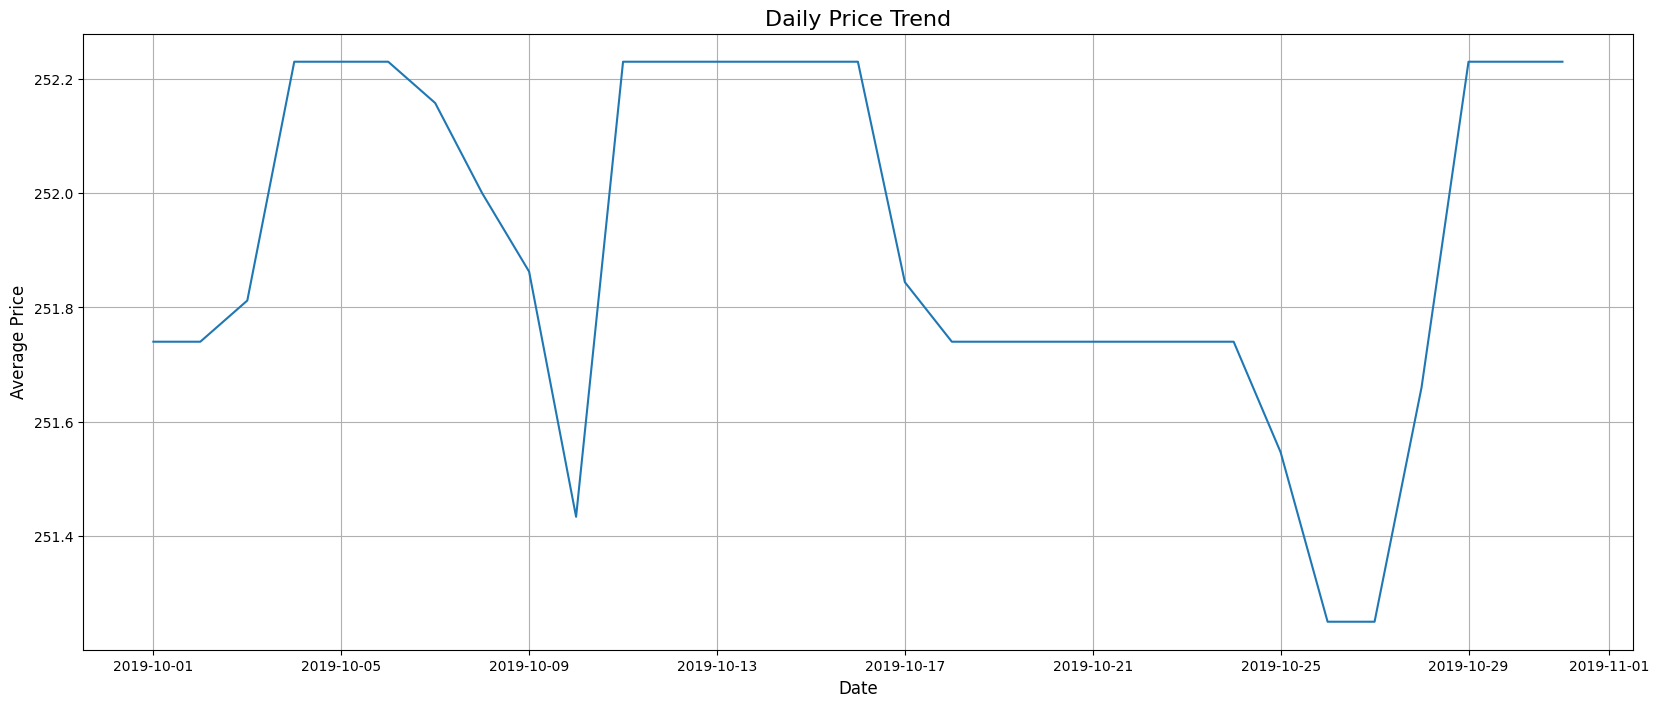

In [12]:
x = product_daily_price["event_date"]
y = product_daily_price["price"]

plt.rcParams["figure.figsize"] = (20, 8)
plt.plot(x, y)
plt.title("Daily Price Trend", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Price", fontsize=12)
plt.grid(True)
plt.show()

## Top 30 Categories (Treemap)

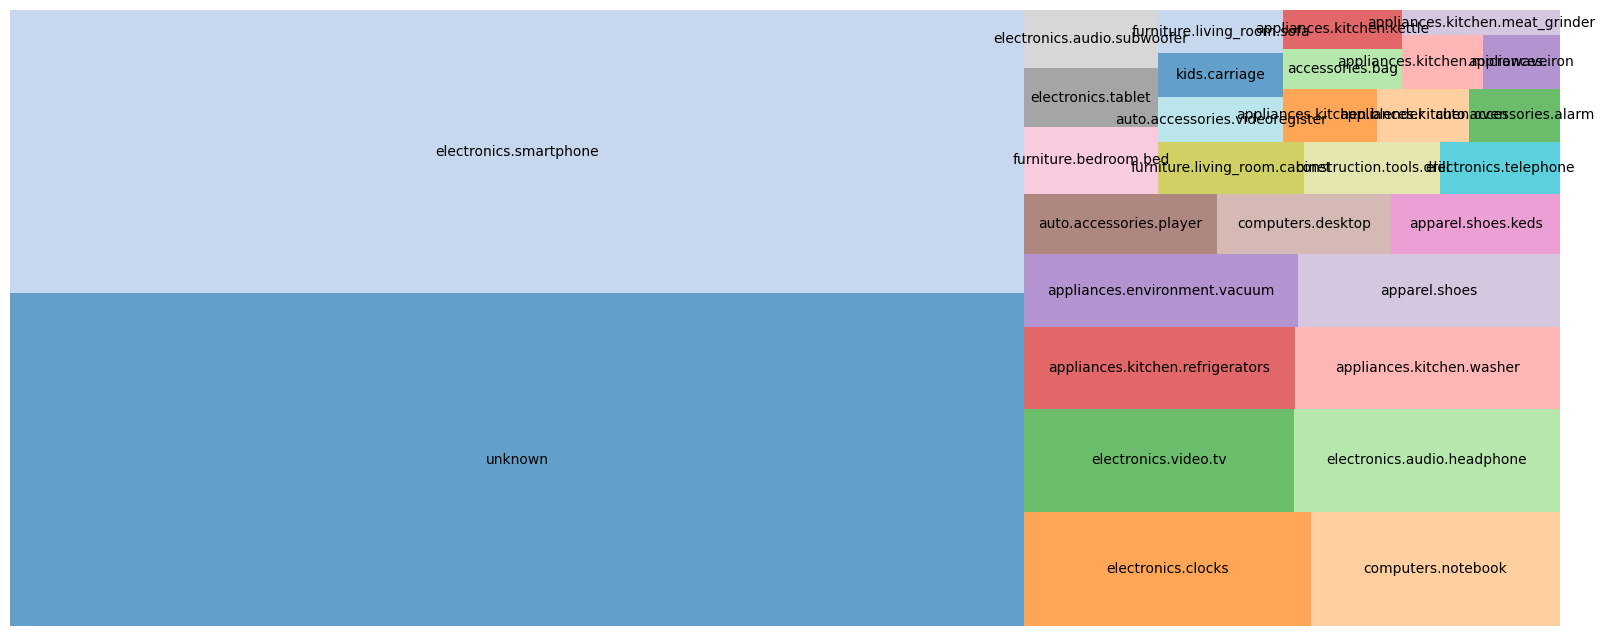

In [13]:
top_category = (
    data.get_column("category_code")
    .value_counts()
    .sort("count", descending=True)
    .head(30)
)
sizes = top_category["count"].to_list()
labels = top_category["category_code"].to_list()
colors = plt.cm.tab20.colors

squarify.plot(sizes=sizes, label=labels, color=colors, alpha=0.7)
plt.axis("off")
plt.show()

## Top 30 Brands (Treemap)

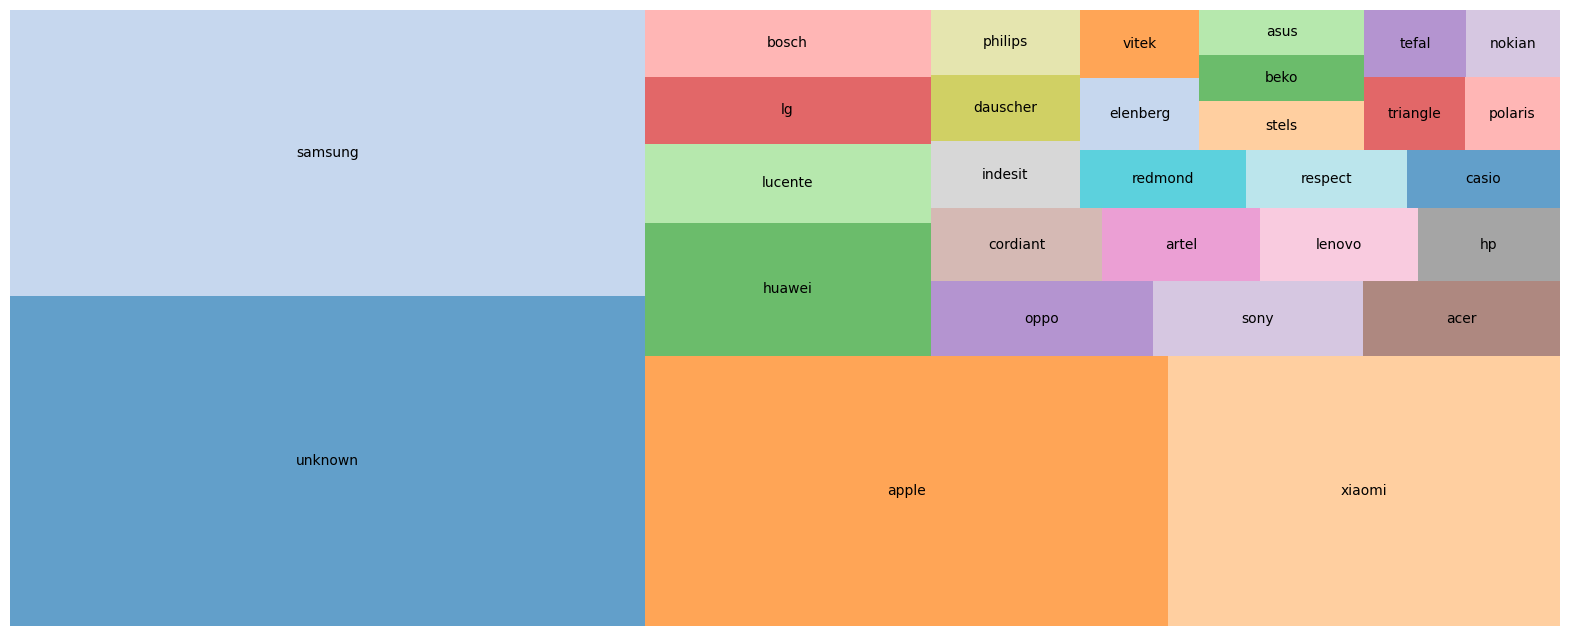

In [14]:
top_brand = (
    data.get_column("brand")
    .value_counts()
    .sort("count", descending=True)
    .head(30)
)
sizes = top_brand["count"].to_list()
labels = top_brand["brand"].to_list()
colors = plt.cm.tab20.colors

squarify.plot(sizes=sizes, label=labels, color=colors, alpha=0.7)
plt.axis("off")
plt.show()

## Event Type Distribution

In [15]:
data["event_type"].value_counts()

event_type,count
str,u32
"""cart""",926514
"""view""",40779399
"""purchase""",742849


## Top 20 Brands by Event Count

In [16]:
top_sellers = (
    data.group_by("brand")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .head(20)
)
top_sellers

brand,count
str,u32
"""unknown""",6113008
"""samsung""",5282774
"""apple""",4122554
"""xiaomi""",3083763
"""huawei""",1111205
…,…
"""indesit""",290101
"""dauscher""",289853
"""philips""",282699


## Predict Purchase at Cart Addition Time
### Feature Engineering

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn import metrics

In [18]:
# ── Sắp xếp theo thời gian trước ──────────────────────────────────────────────
data = data.sort(["user_id", "event_time"])

# ── 1. User features — chỉ tính TRƯỚC thời điểm cart ─────────────────────────
user_features = (
    data
    .filter(pl.col("event_type") != "cart")   # loại cart ra, chỉ dùng view/purchase trước đó
    .group_by("user_id")
    .agg([
        # (pl.col("event_type") == "purchase").sum().alias("user_total_purchases"),
        (pl.col("event_type") == "view").sum().alias("user_total_views"),
        (
            (pl.col("event_type") == "purchase").sum()
            / pl.col("event_type").count().clip(lower_bound=1)
        ).alias("user_purchase_rate"),          # đổi tên rõ hơn
        pl.col("price").filter(pl.col("event_type") == "purchase")
          .mean().alias("user_avg_purchase_price"),
        pl.col("event_date").n_unique().alias("user_active_days"),
        pl.col("user_session").n_unique().alias("user_total_sessions"),
    ])
)

# ── 2. Product features — tính trên toàn dataset (product là global signal) ───
# Product popularity KHÔNG bị leakage vì là thuộc tính của sản phẩm, không của user
product_features = (
    data
    .group_by("product_id")
    .agg([
        (pl.col("event_type") == "purchase").sum().alias("product_total_purchases"),
        (pl.col("event_type") == "cart").sum().alias("product_total_carts"),
        (
            (pl.col("event_type") == "purchase").sum()
            / (pl.col("event_type") == "cart").sum().clip(lower_bound=1)
        ).alias("product_cart_to_purchase_rate"),
        pl.col("user_id").filter(pl.col("event_type") == "view")
          .n_unique().alias("product_unique_viewers"),
        pl.col("price").mean().alias("product_avg_price"),
        pl.col("price").std().fill_null(0).alias("product_price_std"),
    ])
)

# ── 3. Session features — KHÔNG tính purchase (chỉ biết trước khi cart) ───────
session_features = (
    data
    .filter(pl.col("event_type") == "view")    # chỉ lấy view trong session
    .group_by("user_session")
    .agg([
        pl.len().alias("session_view_count"),
        pl.col("product_id").n_unique().alias("session_unique_products"),
        (pl.col("price").max() - pl.col("price").min()).alias("session_price_range"),
    ])
)

# ── 4. User × Product — ĐÂY LÀ LEAKAGE NẶNG NHẤT, fix hoàn toàn ─────────────
# Chỉ đếm view/purchase của user với product này TRƯỚC lần cart hiện tại
# Dùng shift để lấy lịch sử trước đó
user_product_features = (
    data
    .filter(pl.col("event_type").is_in(["view", "purchase"]))
    .group_by(["user_id", "product_id"])
    .agg([
        (pl.col("event_type") == "view").sum().alias("user_product_view_count"),
        # purchased_before: chỉ có ý nghĩa nếu là purchase TRƯỚC cart
        # Với 1 tháng data, an toàn nhất là bỏ hoặc dùng binary flag
        ((pl.col("event_type") == "purchase").sum() > 0)
          .cast(pl.Int8).alias("user_ever_purchased_product"),  # 0/1 thay vì count
    ])
)

In [19]:
# Users who have cart or purchase events
cart_purchase_user_ids = (
    data.filter(pl.col("event_type").is_in(["cart", "purchase"]))
    .select("user_id")
    .unique()
)

In [20]:
# Count activity per session for those users
activity_in_session = (
    data.join(cart_purchase_user_ids, on="user_id", how="inner")
    .group_by("user_session")
    .agg(pl.len().alias("activity_count"))
)

In [21]:
# Build target labels: was the cart item eventually purchased?
df_targets = (
    data.filter(pl.col("event_type").is_in(["cart", "purchase"]))
    .unique(subset=["event_type", "product_id", "price", "user_id", "user_session"])
    .with_columns(
        pl.when(pl.col("event_type") == "purchase").then(1).otherwise(0).alias("is_purchased")
    )
    .with_columns(
        pl.col("is_purchased").max().over(["user_session", "product_id"])
    )
)

In [22]:
# Keep only cart events; extract features
df_targets = (
    df_targets.filter(pl.col("event_type") == "cart")
    .unique(subset=["user_session", "product_id", "is_purchased"])
    .drop_nulls()
    .with_columns([
        pl.col("event_date").dt.weekday().alias("event_weekday"),
        pl.col("category_code").str.split(".").list.get(0).alias("category_code_level1"),
        pl.col("category_code").str.split(".").list.get(1, null_on_oob=True).alias("category_code_level2"),
    ])
)

In [23]:
# Join activity count
df_targets = (
    df_targets.join(activity_in_session, on="user_session", how="left")
    .with_columns(pl.col("activity_count").fill_null(0))
)

In [24]:
# ── 5. Merge tất cả vào df_targets ────────────────────────────────────────────
df_rich = (
    df_targets
    .join(user_features,         on="user_id",    how="left")
    .join(product_features,      on="product_id", how="left")
    .join(session_features,      on="user_session", how="left")
    .join(user_product_features, on=["user_id", "product_id"], how="left")
    .with_columns([
        # Price so với avg của user (user này hay mua đắt hay rẻ?)
        # (pl.col("price") / pl.col("user_avg_purchase_price").fill_null(1)).alias("price_vs_user_avg"),
 
        # Price so với avg của sản phẩm
        (pl.col("price") / pl.col("product_avg_price").fill_null(1)).alias("price_vs_product_avg"),
 
        # User có "intent" cao không (cart nhiều mà ít mua = thấp)
        pl.col("product_cart_to_purchase_rate").fill_null(0),
        pl.col("user_product_view_count").fill_null(0),
    ])
)

In [25]:
df_rich.head()

event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_date,is_purchased,event_weekday,category_code_level1,category_code_level2,activity_count,user_total_views,user_purchase_rate,user_avg_purchase_price,user_active_days,user_total_sessions,product_total_purchases,product_total_carts,product_cart_to_purchase_rate,product_unique_viewers,product_avg_price,product_price_std,session_view_count,session_unique_products,session_price_range,user_product_view_count,user_ever_purchased_product,price_vs_product_avg
str,str,i64,i64,str,str,f32,i64,str,date,i32,i8,str,str,u32,u32,f64,f32,u32,u32,u32,u32,f64,u32,f32,f32,u32,u32,f32,u32,i8,f32
"""2019-10-27 08:36:41 UTC""","""cart""",1004785,2053013555631882655,"""electronics.smartphone""","""huawei""",256.890015,541252412,"""ca0d7bfc-90db-4c53-80cf-7ac524…",2019-10-27,0,7,"""electronics""","""smartphone""",5,30,0.032258,189.970001,5,9,3506,6573,0.533394,48888,270.487152,6.934524,3,2,66.920013,5,0,0.949731
"""2019-10-15 05:40:07 UTC""","""cart""",1801805,2053013554415534427,"""electronics.video.tv""","""artel""",239.360001,560349216,"""a96a8987-96c4-4653-ac34-b38581…",2019-10-15,1,2,"""electronics""","""video""",4,83,0.023529,239.355011,7,17,683,934,0.731263,9963,236.923279,8.120711,2,1,0.0,34,1,1.010285
"""2019-10-27 06:29:22 UTC""","""cart""",3100117,2053013555262783879,"""appliances.kitchen.blender""","""panasonic""",47.360001,526866553,"""4f1a9de2-aa80-48e7-91f8-6b7fd1…",2019-10-27,1,7,"""appliances""","""kitchen""",12,20,0.090909,118.129997,4,4,25,67,0.373134,704,47.271786,0.533359,10,4,34.979996,2,1,1.001866
"""2019-10-15 06:36:59 UTC""","""cart""",1004875,2053013555631882655,"""electronics.smartphone""","""samsung""",386.290009,535937973,"""202c1789-a68b-4e63-812d-142e3e…",2019-10-15,0,2,"""electronics""","""smartphone""",27,79,0.0,null,8,9,1170,2063,0.567135,20876,375.09967,11.827032,26,17,1318.51001,5,0,1.029833
"""2019-10-16 04:41:05 UTC""","""cart""",1004750,2053013555631882655,"""electronics.smartphone""","""samsung""",195.619995,558333870,"""a15360ba-d379-4ba0-9c7a-03e618…",2019-10-16,1,3,"""electronics""","""smartphone""",10,197,0.112613,247.042404,17,32,4597,8182,0.561843,52422,196.517288,1.404501,6,2,92.029999,7,1,0.995434


In [26]:
df_rich.schema

Schema([('event_time', String),
        ('event_type', String),
        ('product_id', Int64),
        ('category_id', Int64),
        ('category_code', String),
        ('brand', String),
        ('price', Float32),
        ('user_id', Int64),
        ('user_session', String),
        ('event_date', Date),
        ('is_purchased', Int32),
        ('event_weekday', Int8),
        ('category_code_level1', String),
        ('category_code_level2', String),
        ('activity_count', UInt32),
        ('user_total_views', UInt32),
        ('user_purchase_rate', Float64),
        ('user_avg_purchase_price', Float32),
        ('user_active_days', UInt32),
        ('user_total_sessions', UInt32),
        ('product_total_purchases', UInt32),
        ('product_total_carts', UInt32),
        ('product_cart_to_purchase_rate', Float64),
        ('product_unique_viewers', UInt32),
        ('product_avg_price', Float32),
        ('product_price_std', Float32),
        ('session_view_count', UInt32),

### Prepare ML Features

In [27]:
is_purchase_set = df_rich.filter(pl.col("is_purchased") == 1)
not_purchase_set = df_rich.filter(pl.col("is_purchased") == 0)
is_purchase_set.shape, not_purchase_set.shape

((304940, 32), (323267, 32))

In [28]:
# Downsample both classes to 700k for balanced training
n_samples = 300_000
is_purchase_sampled = resample(is_purchase_set.to_pandas(), replace=False, n_samples=n_samples, random_state=27)
not_purchase_sampled = resample(not_purchase_set.to_pandas(), replace=False, n_samples=n_samples, random_state=27)

In [29]:
import pandas as pd

df_balanced = pd.concat([is_purchase_sampled, not_purchase_sampled])

# Fill NaN in categorical columns with 'unknown'
cat_cols = ["brand", "category_code_level1", "category_code_level2"]
df_balanced[cat_cols] = df_balanced[cat_cols].fillna("unknown")

# Convert event_weekday to string for CatBoost
df_balanced["event_weekday"] = df_balanced["event_weekday"].astype(str)

feature_cols = [
    # --- Categorical ---
    "brand",
    "category_code_level1",
    "category_code_level2",
    "event_weekday",

    # --- User behavior (quan trọng nhất) ---
    # "user_total_purchases",         # user mua nhiều hay ít?
    "user_total_sessions",
    "user_active_days",

    # --- Product popularity ---
    "product_cart_to_purchase_rate", # sản phẩm này có tỉ lệ mua cao không?
    "product_total_purchases",
    "product_unique_viewers",

    # --- Session intent ---
    "activity_count",               # session dài → intent cao
    "session_view_count",
    "session_unique_products",

    # --- Price signals ---
    "price",
    # "price_vs_user_avg",            # giá này rẻ/đắt so với thói quen user?
    "price_vs_product_avg",

    # --- User × Product interaction ---
    "user_product_view_count",      # đã xem sản phẩm này bao nhiêu lần?
]
X = df_balanced[feature_cols]
y = df_balanced["is_purchased"]

X.head()

,brand,category_code_level1,category_code_level2,event_weekday,user_total_sessions,user_active_days,product_cart_to_purchase_rate,product_total_purchases,product_unique_viewers,activity_count,session_view_count,session_unique_products,price,price_vs_product_avg,user_product_view_count
53736,apple,electronics,audio,4,13.0,8.0,0.543957,12381,70519,7,5.0,1.0,160.610001,0.999240,6
72729,haier,electronics,video,5,10.0,6.0,0.594488,453,6807,3,1.0,1.0,231.639999,0.981415,7
93950,apple,electronics,audio,5,5.0,4.0,0.543957,12381,70519,8,4.0,1.0,161.839996,1.006892,4
228369,samsung,electronics,smartphone,6,1.0,1.0,0.518909,2607,33092,13,8.0,4.0,250.380005,1.005387,3
169582,apple,electronics,smartphone,1,13.0,6.0,0.624399,9090,96989,8,6.0,3.0,745.940002,1.008023,8


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

### Model: CatBoost

In [31]:
# from catboost import CatBoostClassifier

# cat_features = ["brand", "event_weekday", "category_code_level1", "category_code_level2"]

# cat_model = CatBoostClassifier(
#     iterations=2000,
#     learning_rate=0.05,
#     depth=8,
#     auto_class_weights="Balanced",
#      early_stopping_rounds=100,
#     eval_metric="Accuracy",
#     random_seed=42,
#     task_type="CPU",
#     verbose=100,
# )

# cat_model.fit(
#     X_train,
#     y_train,
#     cat_features=cat_features,
#     eval_set=(X_test, y_test),
# )

# y_pred = cat_model.predict(X_test)

# print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
# print("Precision:", metrics.precision_score(y_test, y_pred))
# print("Recall:", metrics.recall_score(y_test, y_pred))
# print("F-beta (weighted, beta=0.5):", metrics.fbeta_score(y_test, y_pred, average="weighted", beta=0.5))

### Model XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn import metrics
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

cat_cols = ["brand", "event_weekday", "category_code_level1", "category_code_level2"]

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()
X_train_enc[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test_enc[cat_cols] = encoder.transform(X_test[cat_cols])

xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="logloss",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True
)

xgb_model.fit(
    X_train_enc, y_train,
    eval_set=[(X_train_enc, y_train), (X_test_enc, y_test)],
    verbose=50,
)
xgb_model.save_model("/home/chien/Big_Data/checkpoint/xgboost/xgb_model_v2.json")
y_pred_xgb = xgb_model.predict(X_test_enc)

results = xgb_model.evals_result()
print("=== XGBoost ===")
print("Accuracy :", metrics.accuracy_score(y_test, y_pred_xgb))
print("Precision:", metrics.precision_score(y_test, y_pred_xgb))
print("Recall   :", metrics.recall_score(y_test, y_pred_xgb))
print("F-beta   :", metrics.fbeta_score(y_test, y_pred_xgb, average="weighted", beta=0.5))

[0]	validation_0-logloss:0.68386	validation_1-logloss:0.68396
[50]	validation_0-logloss:0.47699	validation_1-logloss:0.47755
[100]	validation_0-logloss:0.40903	validation_1-logloss:0.40949
[150]	validation_0-logloss:0.38042	validation_1-logloss:0.38091
[200]	validation_0-logloss:0.36647	validation_1-logloss:0.36740
[250]	validation_0-logloss:0.35798	validation_1-logloss:0.35959
[300]	validation_0-logloss:0.35269	validation_1-logloss:0.35509
[350]	validation_0-logloss:0.34845	validation_1-logloss:0.35159
[400]	validation_0-logloss:0.34513	validation_1-logloss:0.34904
[450]	validation_0-logloss:0.34245	validation_1-logloss:0.34723
[500]	validation_0-logloss:0.34035	validation_1-logloss:0.34592
[550]	validation_0-logloss:0.33837	validation_1-logloss:0.34477
[600]	validation_0-logloss:0.33676	validation_1-logloss:0.34406
[650]	validation_0-logloss:0.33518	validation_1-logloss:0.34333
[700]	validation_0-logloss:0.33374	validation_1-logloss:0.34275
[750]	validation_0-logloss:0.33240	validati

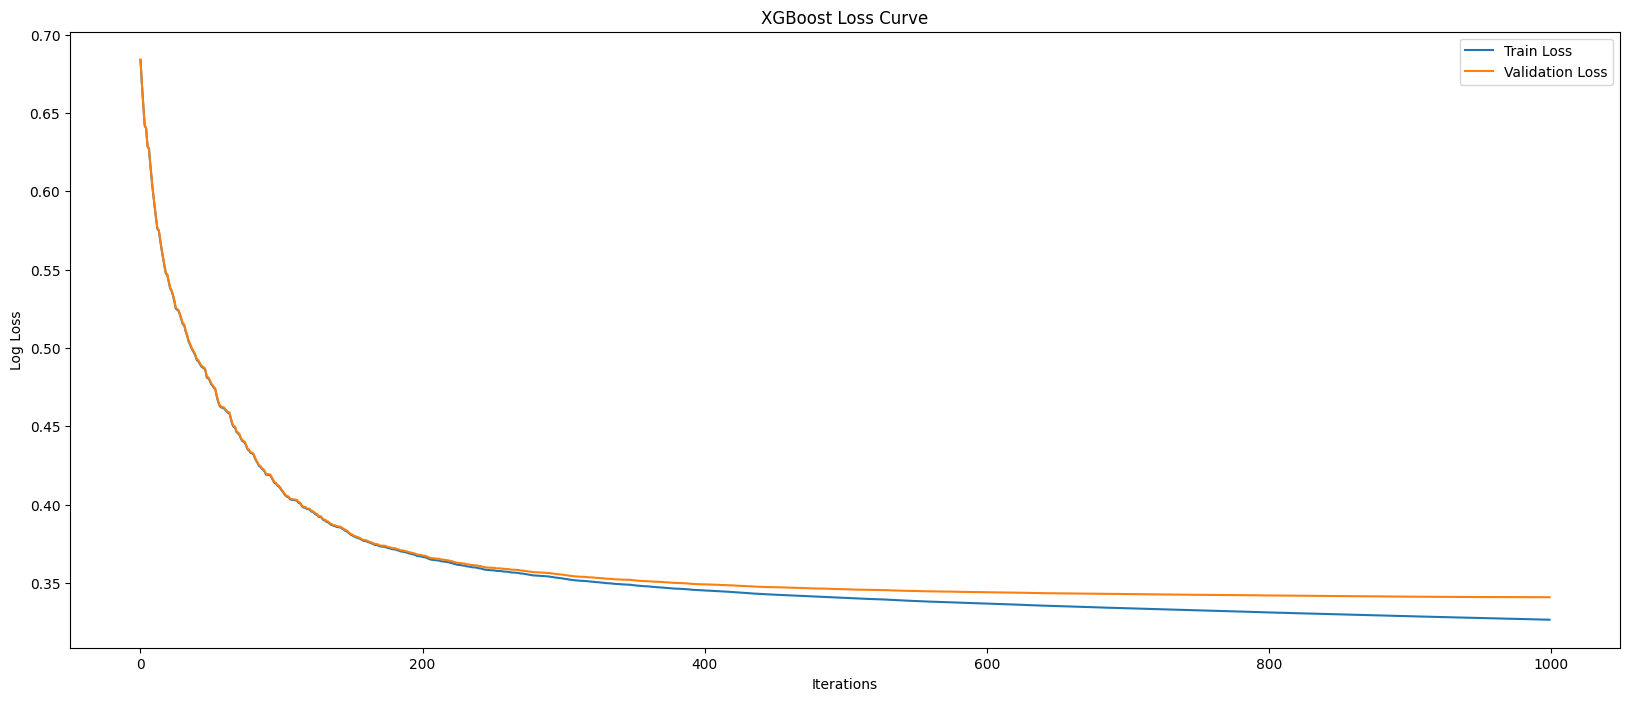

In [33]:
import matplotlib.pyplot as plt

results = xgb_model.evals_result()

train_loss = results["validation_0"]["logloss"]
val_loss = results["validation_1"]["logloss"]

plt.figure()
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("XGBoost Loss Curve")
plt.legend()
plt.show()

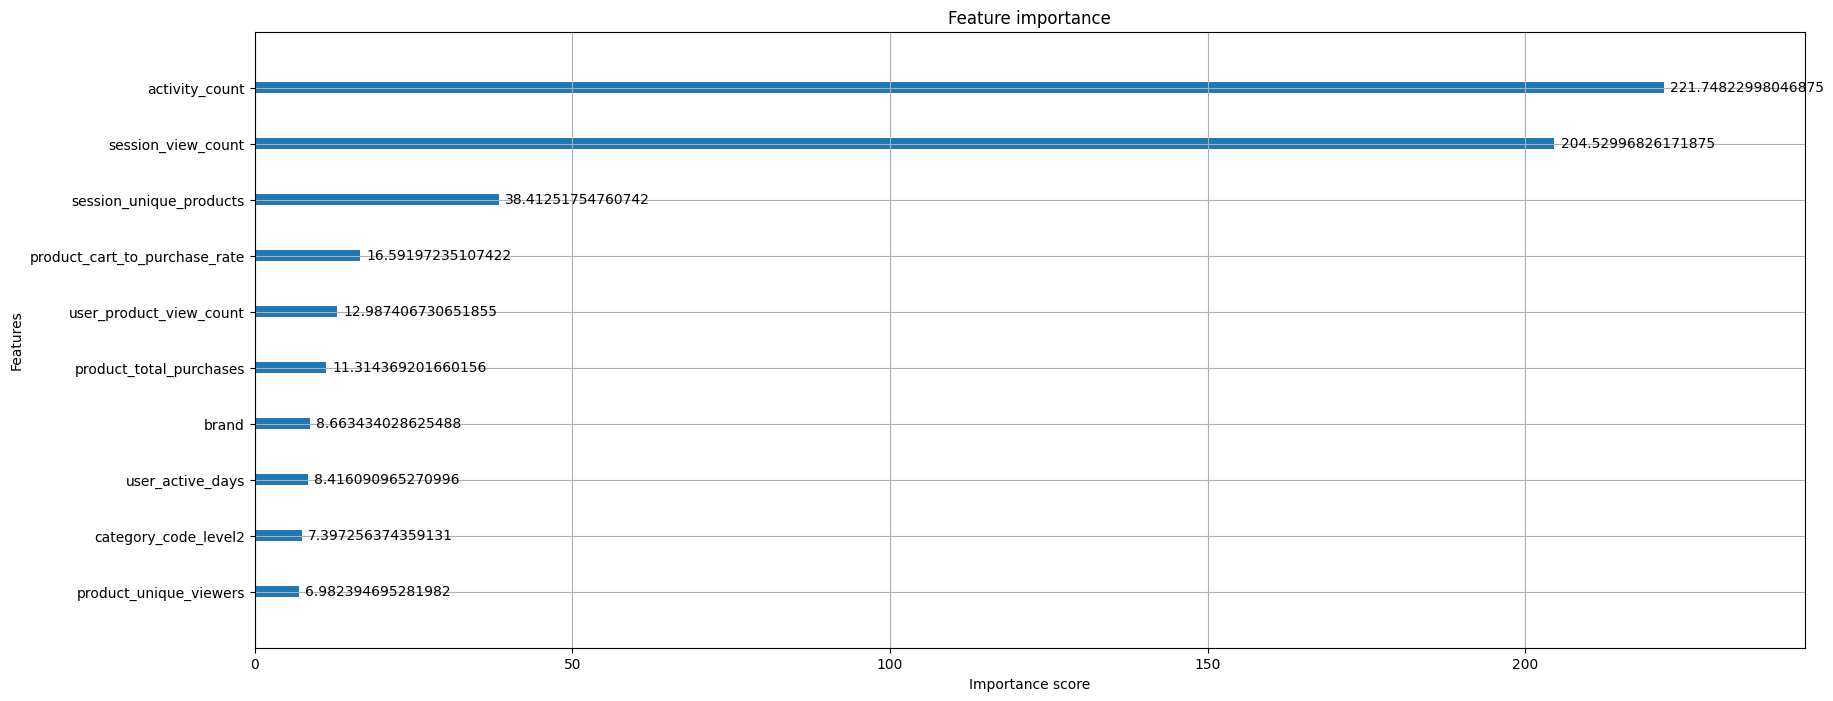

In [34]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(xgb_model, importance_type='gain', max_num_features=10)
plt.show()